In [2]:
from qutip import *
import numpy as np
from scipy import constants
import datetime
import time
import gc
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocessing as mp
from numpy.linalg import inv
from numpy import linalg as LA
from scipy.optimize import minimize_scalar
import math
from scipy.optimize import curve_fit
from scipy.sparse.linalg import eigs

In [3]:
plt.rcdefaults()
from matplotlib import rc
import matplotlib as mpl
 
rc('text', usetex=True)
rc("mathtext", fontset = "cm")
rc("font", family="DejaVu Serif", serif="Times New Roman")

In [4]:
#                       |e> 
#                    --------
#                    /     \
#  Δg, Ωg (probe!)  /       \  Δr, Ωr
#                  /         \ 
#                 /        -------
#             -------        |r> 
#               |g> 

In [5]:
#basis {e,r,g}
N = 3
e = basis(N,0)
r = basis(N,1)
g = basis(N,2)

## Absorption profile of rest ion

In [6]:
def pope(Gamma, Deltar, Omegag, Omegar, Deltag_min, Deltag_max, nn):
    #rhos = []
    pop_e = []
    #tstart = time.time();

    #linbland operator/collapse operators
    #c1 = sqrt(Gamma/3)*p*e.dag()
    c2 = np.sqrt(Gamma/2)*r*e.dag()
    c3 = np.sqrt(Gamma/2)*g*e.dag()
    
    c = [c2,c3]
    #c = [c3]
    c_ops =[spre(c[i])*spost(c[i].dag()) - 0.5*(spre(c[i].dag()*c[i]) + spost(c[i].dag()*c[i])) for i in range(N-1)]

    for Deltag in tqdm(np.linspace(Deltag_min,Deltag_max,nn)):

        #Hamiltonian for a rest ion
        H1 = Deltag*g*g.dag() + Deltar*r*r.dag()
        H2 = -0.5*(Omegag*e*g.dag() + Omegar*e*r.dag() + Omegag*g*e.dag() + Omegar*r*e.dag())
        H = H1 + H2
        

        rho = steadystate(H,c)

        #rhos.append(rho)
    
        pop_e.append(expect(e*e.dag(),rho))
        #print(i)
    
    #print('running time = '+str(time.time()-tstart)+' seconds')
    
    return pop_e#,rhos

In [7]:
#parameters (MHz/2π)
Gamma = 20
Omegar = 17
Omegag = 1
Deltar = 70
Deltag = Deltar
omega = Gamma/20
Dmin = 67
Dmax = 73
nn = 2000 #Deltap points


params = dict(Gamma=Gamma, Deltar=Deltar, Omegag=Omegag, Omegar=Omegar,
             Deltag_min=Dmin, Deltag_max=Dmax, nn=nn)

In [8]:
pop_e1 = pope(**params)

100%|██████████| 2000/2000 [00:00<00:00, 3707.94it/s]


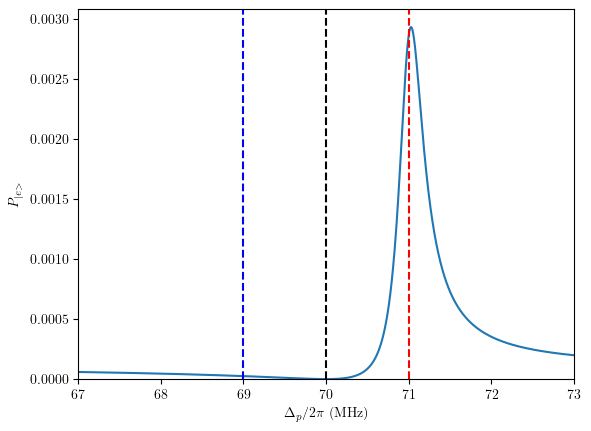

In [9]:
plt.figure()

plt.plot(np.linspace(Dmin,Dmax,nn),pop_e1)


plt.axvline(70+ omega, linestyle='--',color='red')
plt.axvline(70 , linestyle='--',color='black')
plt.axvline(70 - omega, linestyle='--',color='blue')
plt.ylabel('$P_{|e>}$')
plt.xlabel('$\Delta_{p}/2\pi$ (MHz)')
plt.ylim(0)

plt.xlim(67,73)

plt.show()

In [10]:
#parameters G.Morigi PRL (MHz)
Gamma = 20
Omegar = 17
Omegag = 2
Deltar = 70
Deltag = Deltar
omega = Gamma/20
Dmin = 67
Dmax = 73
nn = 2000 #Deltap points


params = dict(Gamma=Gamma, Deltar=Deltar, Omegag=Omegag, Omegar=Omegar,
             Deltag_min=Dmin, Deltag_max=Dmax, nn=nn)

In [11]:
pop_e2 = pope(**params)

100%|██████████| 2000/2000 [00:00<00:00, 3662.90it/s]


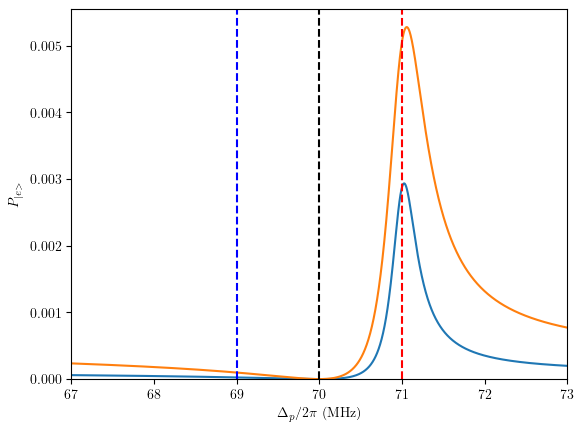

In [12]:
plt.figure()

plt.plot(np.linspace(Dmin,Dmax,nn),pop_e1)
plt.plot(np.linspace(Dmin,Dmax,nn),pop_e2)


plt.axvline(70+ omega, linestyle='--',color='red')
plt.axvline(70 , linestyle='--',color='black')
plt.axvline(70 - omega, linestyle='--',color='blue')
plt.ylabel('$P_{|e>}$')
plt.xlabel('$\Delta_{p}/2\pi$ (MHz)')
plt.ylim(0)

plt.xlim(67,73)

plt.show()

In [13]:
#parameters G.Morigi PRL (MHz)
Gamma = 20
Omegar = 17
Omegag = 3
Deltar = 70
Deltag = Deltar
omega = Gamma/20
Dmin = 67
Dmax = 73
nn = 2000 #Deltap points
step = (Dmax-Dmin)/nn


params = dict(Gamma=Gamma, Deltar=Deltar, Omegag=Omegag, Omegar=Omegar,
             Deltag_min=Dmin, Deltag_max=Dmax, nn=nn)

In [14]:
pop_e3 = pope(**params)

100%|██████████| 2000/2000 [00:00<00:00, 3476.30it/s]


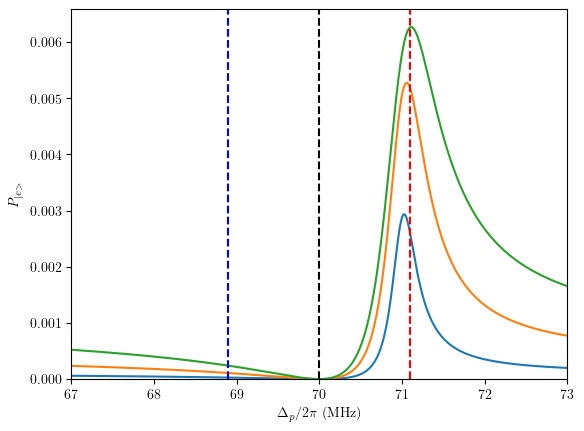

In [15]:
plt.figure()
plt.plot(np.linspace(Dmin,Dmax,nn),pop_e1)
plt.plot(np.linspace(Dmin,Dmax,nn),pop_e2)
plt.plot(np.linspace(Dmin,Dmax,nn),pop_e3)

plt.axvline(70+ 1.1, linestyle='--',color='red')
plt.axvline(70 , linestyle='--',color='black')
plt.axvline(70 - 1.1, linestyle='--',color='blue')
plt.ylabel('$P_{|e>}$')
plt.xlabel('$\Delta_{p}/2\pi$ (MHz)')
plt.ylim(0)

plt.xlim(67,73)
plt.show()

In [16]:
eta=0.01
step = (Dmax-Dmin)/nn

In [17]:
Deltar

70

In [18]:
wabs = eta**2*2*np.pi*Gamma*np.array([pop_e1[int((Deltar+omega - Dmin)/step)] - pop_e1[int((Deltar - omega - Dmin)/step)], 
                 pop_e2[int((Deltar+omega - Dmin)/step)] - pop_e2[int((Deltar - omega - Dmin)/step)],
                 pop_e3[int((Deltar+omega - Dmin)/step)] - pop_e3[int((Deltar-omega - Dmin)/step)]
                ])

In [17]:
wabs

array([3.57824848e-05, 6.22538890e-05, 6.99585560e-05])

## Cooling

In [ ]:
t1 = np.loadtxt(""+str(path_name)+"cooling_EIT_Omegag_1_Omegar_17_Delta_70_Gamma1_10.0_Gamma2_10.0_eta_0.01_omega_1.1.txt")[:, 0]
n1 = np.loadtxt(""+str(path_name)+"cooling_EIT_Omegag_1_Omegar_17_Delta_70_Gamma1_10.0_Gamma2_10.0_eta_0.01_omega_1.1.txt")[:, 1]

In [ ]:
t2 = np.loadtxt(""+str(path_name)+"cooling_EIT_Omegag_2_Omegar_17_Delta_70_Gamma1_10.0_Gamma2_10.0_eta_0.01_omega_1.1.txt")[:, 0]
n2 = np.loadtxt(""+str(path_name)+"cooling_EIT_Omegag_2_Omegar_17_Delta_70_Gamma1_10.0_Gamma2_10.0_eta_0.01_omega_1.1.txt")[:, 1]

In [ ]:
t3 = np.loadtxt(""+str(path_name)+"cooling_EIT_Omegag_3_Omegar_17_Delta_70_Gamma1_10.0_Gamma2_10.0_eta_0.01_omega_1.1.txt")[:, 0]
n3 = np.loadtxt(""+str(path_name)+"cooling_EIT_Omegag_3_Omegar_17_Delta_70_Gamma1_10.0_Gamma2_10.0_eta_0.01_omega_1.1.txt")[:, 1]

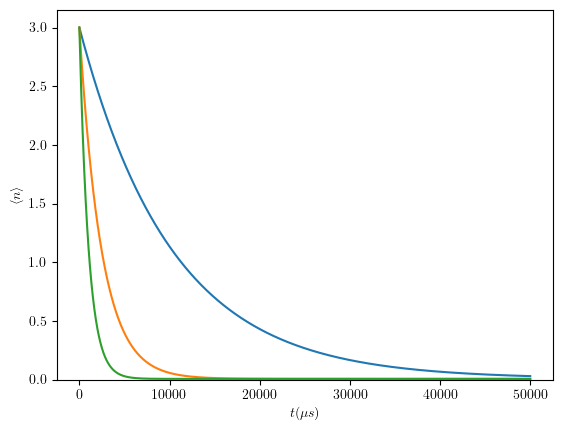

In [24]:
plt.figure()
#plt.title("I=1")

#plt.plot(np.linspace(-10*GammaJgJe,20*GammaJgJe,200),pope1)
plt.plot(t1,n1)
plt.plot(t2,n2)
plt.plot(t3,n3)

plt.ylabel('$\\langle n \\rangle$')
plt.xlabel('$t (\mu s)$')
plt.ylim(0)
#plt.axvline(10.787075035802768, linestyle='--')
#plt.axvline(65, linestyle='--' )
#plt.xlim(0,2)


#plt.legend()
#plt.savefig("I1_cooling_diff_in_state.png",bbox_inches = "tight")
plt.show()

In [25]:
def func(t,a,b,c):
    return a*np.exp(-b*t) + c*(1-np.exp(-b*t))

In [26]:
p0 = (3, .001,.001)
popt1, pcov = curve_fit(func,t1,n1,p0)
popt1

array([3.00137902e+00, 9.77112516e-05, 6.65107123e-03])

In [27]:
p0 = (3, .001,.001)
popt2, pcov = curve_fit(func,t2,n2,p0)
popt2

array([3.00450524e+00, 4.07732206e-04, 6.50558655e-03])

In [28]:
p0 = (3, .001,.001)
popt3, pcov = curve_fit(func,t3,n3,p0)
popt3

array([3.01004984e+00, 9.72271869e-04, 5.94285139e-03])

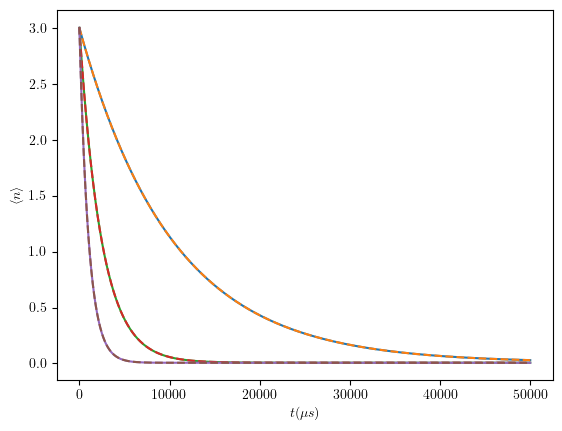

In [30]:

plt.figure()
#plt.title("I=1")

#plt.plot(np.linspace(-10*GammaJgJe,20*GammaJgJe,200),pope1)
plt.plot(t1,n1)
plt.plot(t1,func(t1, *popt1),'--')
plt.plot(t2,n2)
plt.plot(t2,func(t2, *popt2),'--')
plt.plot(t3,n3)
plt.plot(t3,func(t3, *popt3),'--')



plt.ylabel('$\\langle n \\rangle$')
plt.xlabel('$t (\mu s)$')
#plt.ylim(0)
#plt.axvline(10.787075035802768, linestyle='--')
#plt.axvline(65, linestyle='--' )
#plt.xlim(0,2)
#plt.yscale("log")


#plt.legend()
#plt.savefig("I1_cooling_diff_in_state.png",bbox_inches = "tight")
plt.show()

In [31]:
wexp = [popt1[1],popt2[1],popt3[1]]

In [32]:
plt.rcParams.update({'font.size': 8})

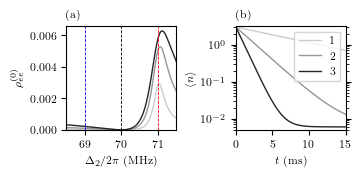

In [37]:
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def format_axes(fig):
    for i, ax in enumerate(fig.axes):
        ax.text(0.5, 0.5, "ax%d" % (i+1), va="center", ha="center")
        ax.tick_params(labelbottom=False, labelleft=False)

fig = plt.figure(constrained_layout=True,figsize=(3.5,1.65))

gs = GridSpec(1, 2, figure=fig)
#gs.update(wspace=0.005, hspace=0.05)
ax1 = fig.add_subplot(gs[0, 0])
# identical to ax1 = plt.subplot(gs.new_subplotspec((0, 0), colspan=3))


ax1.set_title(r'(a)',loc='left',fontdict={'fontsize': 8})
ax1.plot(np.linspace(Dmin,Dmax,nn),pop_e1,color='#cccccc',linewidth=1)
ax1.plot(np.linspace(Dmin,Dmax,nn),pop_e2,color='#969696',linewidth=1)
ax1.plot(np.linspace(Dmin,Dmax,nn),pop_e3,color='#252525',linewidth=1)
ax1.axvline(Deltar + omega, linestyle='--',color='red',linewidth=0.6)
ax1.axvline(Deltar, linestyle='--',color='black',linewidth=0.6)
ax1.axvline(Deltar - omega, linestyle='--',color='blue',linewidth=0.6)
ax1.set_xlim(68.5,71.5)
ax1.set_ylim(0)
ax1.set_ylabel('$\\rho_{ee}^{(0)}$')
ax1.set_xlabel('$\Delta_{2}/2\pi$ (MHz)')


ax4 = fig.add_subplot(gs[0, 1])
ax4.set_title(r'(b)',loc='left',fontdict={'fontsize': 8})
ax4.plot(t1*1e-3,n1,color='#cccccc',label='1',linewidth=1)
ax4.plot(t2*1e-3,n2,color='#969696',label='2',linewidth=1)
ax4.plot(t3*1e-3,n3,color='#252525',label='3',linewidth=1)
#plt.plot(tlist,ne2)
ax4.set_ylabel('$ \\langle n \\rangle $')
ax4.set_xlabel('$t$ (ms)')
ax4.set_yscale('log')
ax4.set_ylim(5e-3,3.2e0)
ax4.set_xlim(0,15)
ax4.legend(loc='upper right',fancybox=False)
ax4.tick_params(axis='y', which='both', left=True, right=True, 
               labelleft=True, labelright=False)


#plt.xlim(45,55)

#fig.suptitle("GridSpec")
#format_axes(fig)

plt.savefig("eit_abs.pdf",bbox_inches = "tight")


plt.show()

In [30]:
n3[-1]

0.00599189